In [59]:
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


In [60]:
import warnings
warnings.filterwarnings('ignore')

In [67]:
goalie_pull_data=pd.read_csv('./data/processed/goalie_pull_data_2011_2021.csv')
goalie_pull_data.head(2)

,game,total_sec,success
0,20112012_100.html.csv,115,0
1,20112012_1002.html.csv,80,0


In [68]:
goalie_pull_data.success.unique()

array([ 0, -1,  1], dtype=int64)

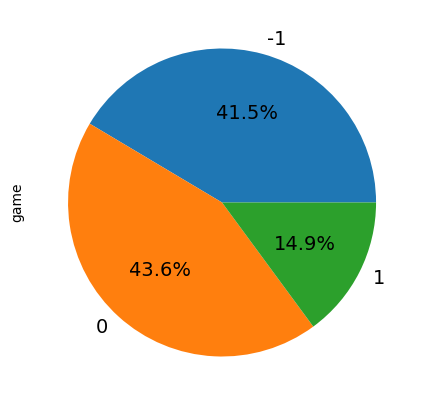

In [69]:
#What was the possiblity of different outcomes goalie pulled
fig, ax=plt.subplots(figsize=(5,5))
goalie_pull_data.groupby('success').count()['game'].plot.pie(autopct="%.1f%%",ax=ax,textprops={'fontsize': 14});

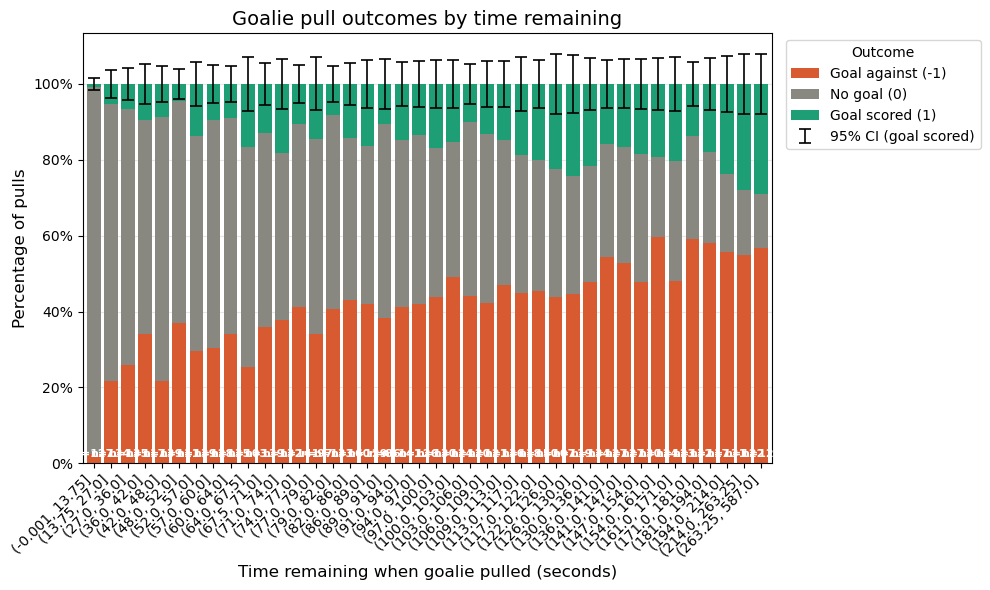

In [70]:
df = goalie_pull_data.copy()
df['bin'] = pd.qcut(df['total_sec'], q=40)

grouped = df.groupby(['bin', 'success']).size().unstack(fill_value=0)
n = grouped.sum(axis=1)
pct = grouped.div(n, axis=0) * 100
pct = pct.rename(columns={-1: 'Goal against (-1)', 0: 'No goal (0)', 1: 'Goal scored (1)'})

# 95% CI for "Goal scored" proportion
p = pct['Goal scored (1)'] / 100
ci = 1.96 * np.sqrt(p * (1 - p) / n) * 100

fig, ax = plt.subplots(figsize=(10, 6))

pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#D85A30', '#888780', '#1D9E75'],
    edgecolor='none',
    width=0.8
)

# error bars sit at the top of the green (Goal scored) segment
tops = pct['Goal against (-1)'] + pct['No goal (0)'] + pct['Goal scored (1)']
x = range(len(pct))
ax.errorbar(
    x, tops, yerr=ci,
    fmt='none', color='black', capsize=4, linewidth=1.2, capthick=1.2,
    label='95% CI (goal scored)'
)

# annotate n per bin
for i, (count, top) in enumerate(zip(n, tops)):
    ax.text(i, 1, f'n={count}', ha='center', va='bottom',
            fontsize=8, color='white', fontweight='bold')

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Time remaining when goalie pulled (seconds)', fontsize=12)
ax.set_ylabel('Percentage of pulls', fontsize=12)
ax.set_title('Goalie pull outcomes by time remaining', fontsize=14)
ax.set_xticklabels([str(b) for b in pct.index], rotation=45, ha='right')
ax.legend(title='Outcome', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [41]:
5000/20

250.0

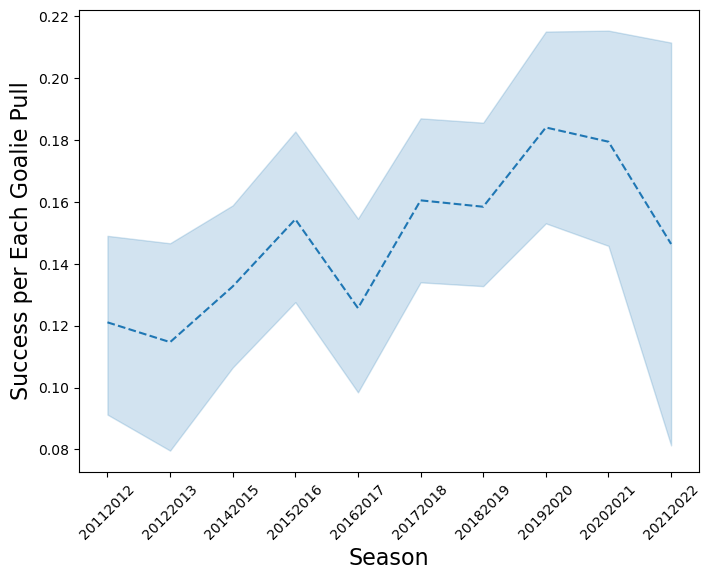

In [65]:
#No goal or one goal received are the same for the team pulling its goalie, so we replace the -1 with 0 in success
goalie_pull_data.loc[goalie_pull_data.success<0,'success']=0
#create season column 
goalie_pull_data['season']=goalie_pull_data.game.apply(lambda x: x.split('_')[0])

#plot the success rate for each season
fig, ax=plt.subplots(figsize=(8,6))
sns.lineplot(data=goalie_pull_data,x='season',y='success',linestyle='--',ax=ax)
ax.set_ylabel('Success per Each Goalie Pull', fontsize=16)
ax.set_xlabel('Season',fontsize=16)
plt.xticks(rotation = 45);

In [71]:
# from your existing baseline calculation
p0 = 0.00141 / 2          # per second, one team, regular play

# estimate p and q from your data
# when goalie is pulled: scoring rate for pulling team
p = len(goalie_pull_data[goalie_pull_data.success == 1]) / goalie_pull_data['total_sec'].sum()

# when goalie is pulled: scoring rate against (empty net goals)
q = len(goalie_pull_data[goalie_pull_data.success == -1]) / goalie_pull_data['total_sec'].sum()

print(f'p (score per second, goalie pulled): {p:.5f}')
print(f'q (concede per second, goalie pulled): {q:.5f}')
print(f'p0 (score per second, regular play): {p0:.5f}')

p (score per second, goalie pulled): 0.00138
q (concede per second, goalie pulled): 0.00384
p0 (score per second, regular play): 0.00071


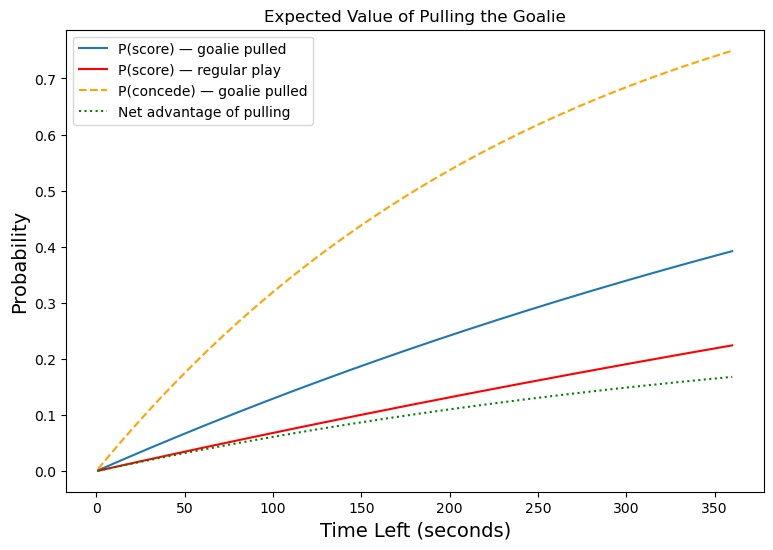

Optimal pull time: 360 seconds = 6.00 minutes


In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

t = np.linspace(1, 360, 360)

# Probability of scoring before time runs out (Poisson process)
P_score_pulled   = 1 - np.exp(-p * t)   # chance you score
P_concede_pulled = 1 - np.exp(-q * t)   # chance they score into empty net

# Net value of pulling = gain from scoring - loss from conceding
# Since down by 1: conceding costs nothing extra, so net value is just P_score_pulled
# BUT: if you DON'T pull, you still have a chance of scoring naturally
P_score_regular  = 1 - np.exp(-p0 * t)

# Advantage of pulling vs not pulling
advantage = P_score_pulled - P_score_regular

plt.figure(figsize=(9, 6))
plt.plot(t, P_score_pulled,  label='P(score) — goalie pulled')
plt.plot(t, P_score_regular, label='P(score) — regular play', color='red')
plt.plot(t, P_concede_pulled, label='P(concede) — goalie pulled', 
         color='orange', linestyle='--')
plt.plot(t, advantage, label='Net advantage of pulling', 
         color='green', linestyle=':')
plt.xlabel('Time Left (seconds)', fontsize=14)
plt.ylabel('Probability', fontsize=14)
plt.legend()
plt.title('Expected Value of Pulling the Goalie')
plt.show()

# Optimal time = where net advantage is maximized
optimal_time = t[np.argmax(advantage)]
print(f'Optimal pull time: {optimal_time:.0f} seconds = {optimal_time/60:.2f} minutes')

p  (score per second, goalie pulled): 0.00138
q  (concede per second, goalie pulled): 0.00384
p0 (score per second, regular play): 0.00071

Optimal pull time: 149s = 2.48 minutes remaining


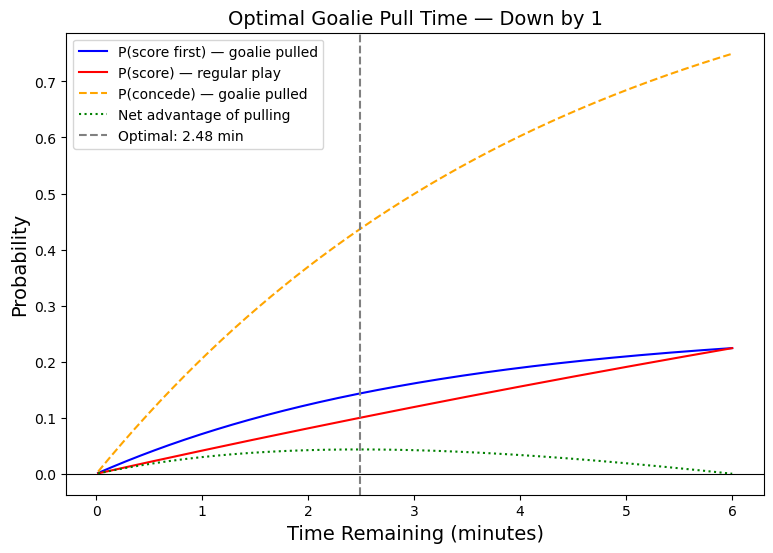

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# --- Reload data to ensure success has original -1, 0, 1 values ---
goalie_pull_data = pd.read_csv('./data/processed/goalie_pull_data_2011_2021.csv')

# --- Rates ---
p0 = 0.00141 / 2          # baseline scoring rate per second, regular play

p = len(goalie_pull_data[goalie_pull_data.success == 1]) / goalie_pull_data['total_sec'].sum()
q = len(goalie_pull_data[goalie_pull_data.success == -1]) / goalie_pull_data['total_sec'].sum()

print(f'p  (score per second, goalie pulled): {p:.5f}')
print(f'q  (concede per second, goalie pulled): {q:.5f}')
print(f'p0 (score per second, regular play): {p0:.5f}')

# --- Probabilities over time ---
t = np.linspace(1, 360, 360)

# Probability you score first — competing Poisson race between p and q
P_you_score_first_pulled = (p / (p + q)) * (1 - np.exp(-(p + q) * t))

# Probability of scoring in regular play
P_score_regular = 1 - np.exp(-p0 * t)

# Probability opponent scores into empty net
P_concede = 1 - np.exp(-q * t)

# Net advantage of pulling vs not pulling
advantage = P_you_score_first_pulled - P_score_regular

# --- Optimal time ---
optimal_time = t[np.argmax(advantage)]
print(f'\nOptimal pull time: {optimal_time:.0f}s = {optimal_time/60:.2f} minutes remaining')

# --- Plot ---
plt.figure(figsize=(9, 6))
plt.plot(t/60, P_you_score_first_pulled, label='P(score first) — goalie pulled', color='blue')
plt.plot(t/60, P_score_regular,          label='P(score) — regular play',         color='red')
plt.plot(t/60, P_concede,                label='P(concede) — goalie pulled',       
         color='orange', linestyle='--')
plt.plot(t/60, advantage,                label='Net advantage of pulling',          
         color='green', linestyle=':')
plt.axvline(optimal_time/60, color='gray', linestyle='--',
            label=f'Optimal: {optimal_time/60:.2f} min')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Time Remaining (minutes)', fontsize=14)
plt.ylabel('Probability', fontsize=14)
plt.title('Optimal Goalie Pull Time — Down by 1', fontsize=14)
plt.legend()
plt.show()

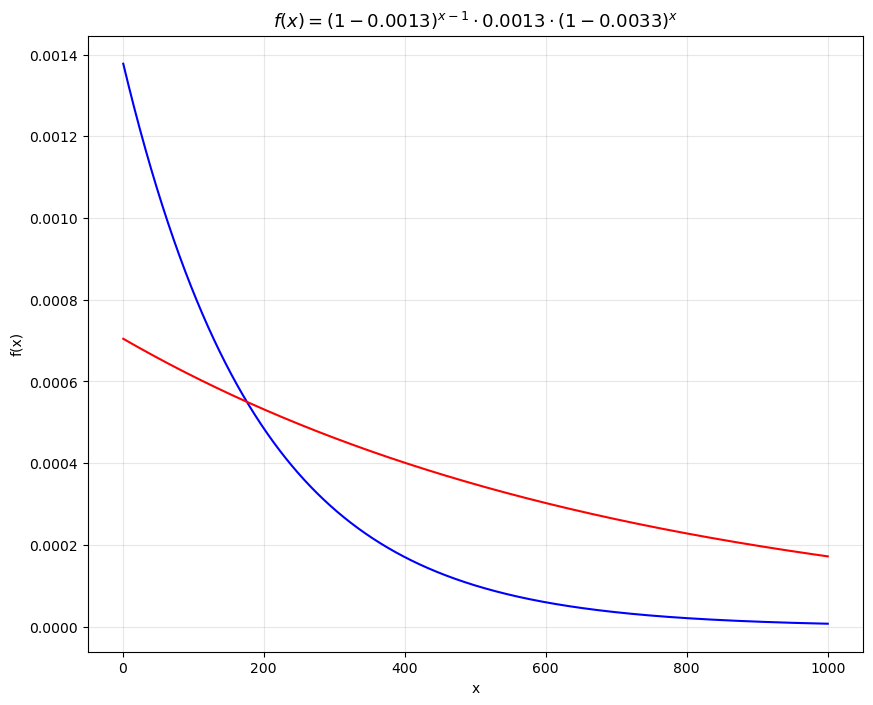

Plot saved.


In [74]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(1, 1000, 10000)

y1 = ((1 - p) ** (x - 1)) * (p) * ((1 - q) ** x)
y2 = ((1 - p0) ** (x - 1)) * (p0) * ((1 - p0) ** x)


fig, axes = plt.subplots(figsize=(10, 8))

axes.plot(x, y1, color='blue', linewidth=1.5)
axes.plot(x, y2, color='red', linewidth=1.5)

axes.set_title('$f(x) = (1-0.0013)^{x-1} \\cdot 0.0013 \\cdot (1-0.0033)^{x}$', fontsize=13)
axes.set_xlabel('x')
axes.set_ylabel('f(x)')
axes.grid(True, alpha=0.3)


plt.show()
print("Plot saved.")